# Mediznische Hochschule Hannover - Mapping

In [1]:
from google.cloud import bigquery
import pandas as pd
from typing import Union
import re
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
sns.set_style('whitegrid')
plt.rc('font', family='Arial')
plt.rc('font', size=9) 
plt.rc('axes', titlesize=9) 
plt.rc('axes', labelsize=9) 
plt.rc('xtick', labelsize=9) 
plt.rc('ytick', labelsize=9) 
plt.rc('legend', fontsize=9)

In [3]:
client = bigquery.Client(project='subugoe-collaborative')

In [4]:
oal = client.query(f"""
                    SELECT 
                        'not assigned' AS inst_name,
                        'Medizinische Hochschule Hannover' AS parent_name,
                        raw_affiliation_string,
                        openalex_id
                    FROM (
                      SELECT oal.id AS openalex_id, inst.address_full AS raw_affiliation_string
                      FROM `subugoe-collaborative.resources.kb_a_addr_inst_202601` AS inst
                      JOIN `subugoe-collaborative.resources.add_institution_lookup_kb_suppl_202601` AS kb_inst
                          ON inst.inst_id_top = kb_inst.inst_id
                      JOIN `subugoe-collaborative.openalex_walden.works` AS oal
                          ON CONCAT('https://openalex.org/', inst.item_id) = oal.id
                      WHERE oal.type IN ('article', 'review') 
                          AND kb_inst.ror = 'https://ror.org/00f2yqf98' -- 'Medizinische Hochschule Hannover'
                          AND is_paratext=FALSE 
                          AND is_retracted=FALSE 
                          AND is_xpac=FALSE
                          AND publication_year BETWEEN 2020 AND 2025
                    )
                    """).to_dataframe()

In [5]:
oal.head()

,inst_name,parent_name,raw_affiliation_string,openalex_id
0,not assigned,Medizinische Hochschule Hannover,"Klinik für Pädiatrische Pneumologie, Allergolo...",https://openalex.org/W4403886593
1,not assigned,Medizinische Hochschule Hannover,"Medizinische Hochschule Hannover, Institut für...",https://openalex.org/W4396679035
2,not assigned,Medizinische Hochschule Hannover,Department of Diagnostic and Interventional Ne...,https://openalex.org/W4396240902
3,not assigned,Medizinische Hochschule Hannover,"Medizinische Hochschule Hannover, Klinik für H...",https://openalex.org/W4395035821
4,not assigned,Medizinische Hochschule Hannover,"Medizinische Hochschule Hannover, Hannover",https://openalex.org/W4395035836


In [43]:
MAPPING_DICT = {
    'Exzellenzcluster RESIST': ['resist'],
    'Forschungs- und Lehreinheit Hebammenwissenschaft': ['hebammenwissenschaft', 'midwifery'],
    'Hannover Biomedical Research School': ['biomedical research'],
    'Hannover Unified Biobank (HUB)': ['biobank'],
    'Institut für Allgemeinmedizin und Palliativmedizin': ['palliativ', 'allgemeinmedizin', 'general practice'],
    'Institut für Molekulare Bakteriologie': ['bacteriology'],
    'Institut für Molekulare und Translationale Therapiestrategien': ['therapeutic strategies'],
    'Institut für Sportmedizin': ['sport(s)? medicine'],
    'Institut für Transplantationsimmunologie': ['transplant(ation)? immunology'],
    'Institut für Zelltherapeutika': ['(ctc)', 'cellular therapeutics'],
    #'Integriertes Forschungs- und Behandlungszentrum Transplantation (IFB-Tx)': [],
    #'Interdisziplinäres Zentrum für Gesichtsfehlbildungen': [],
    'Klinik für Anästhesiologie und Intensivmedizin': ['an(e|ae|ä)sthesiolog(ie|y)', 'intensivmedizin'],
    'Klinik für Dermatologie, Allergologie und Venerologie': ['dermatolog(ie|y)', 'allergy'],
    'Klinik für Frauenheilkunde und Geburtshilfe': ['obstetrics', 'rehabilitati(ve|on)', 'gyn(ae|e|ä)(k|c)olog(ie|y|ist)', 'frauenheilkunde'],
    #'Klinik für Rehabilitationsmedizin': [],
    #'Kopf-Hals-Tumorzentrum Hannover': [],
    'Leibniz Forschungslaboratorien für Biotechnologie und künstliche Organe (LEBAO)': ['(lebao)'],
    'REBIRTH - Forschungszentrum für translationale regenerative Medizin': ['regenerative', 'rebirth( excellence )?cluster'],
    'Research Core Unit for Laser Microscopy': ['laser microscopy'],
    'Twincore': ['twincore'], # selbst ergänzt
    'Zentralapotheke': ['apotheke'],
    'Zentrale Forschungseinrichtung Elektronenmikroskopie': ['electron microscopy'],
    'Zentrale Forschungseinrichtung Genomics': ['genomics'],
    #'Zentrale Forschungswerkstätten': [],
    'Zentrum Anatomie und Zellbiologie': ['applied anatomy', 'neuroanatomy'],
    'Zentrum Augenheilkunde, Hals-Nasen-Ohrenheilkunde, Phoniatrie und Pädaudiologie': ['otorhinolaryngology', 'otol(ogy|ar(yn|ny)gology)', 
                                                                                        'hals(-)?(, )?nasen', 'ophthalmology', 'hno-(klinik|heilkunde)',
                                                                                        'augen(klinik|heilkunde)', 'eye hospital'
                                                                                       ],
    'Zentrum Biochemie': ['(cell|clinical) biochemistry', 'biophysical chemistry', 'zellbiochemie'],
    'Zentrum Biometrie, Medizinische Informatik und Medizintechnik': ['informatics', 'biostatistics'],
    'Zentrum Chirurgie': ['of urology', 'vas(cu|uc)lar', 'plasti(sch|c)', 'trauma', 'orthop(ae|e)dic', 'orthopädische klinik', 'unfallchirurgi(e|sche)',
                          'visceral', 'surgical', 'viszeral', 'thorax', 'kinderchirurgie', 'biomechanics', 'klinik für urologie',
                          'department of surgery'
                         ],
    #'Zentrum für Arzneimittelsicherheit (ZAS)': [],
    'Zentrum für Kinderheilkunde und Jugendmedizin': ['respiratory', 'pulmon(ology|ary)', 'metabolic', 'p(ae|e|ä)diatri(c|sche)', 'pneumolog(ie|y)',
                                                      'cardiothoracic surgery', 'kinderklinik', "children('|’)s hospital", 'kinderheilkunde'
                                                     ],
    'Zentrum für Klinische Studien (ZKS)': ['(zks)', 'cent(re|er) for clinical trials', 'clinical trial center'],
    'Zentrum für Neurologische Medizin': ['neurolog(ie|y)', 'neurosurgery'],
    'Zentrum für Pathologie, Forensik und Genetik': ['patholog(ie|y)', 'human genetics', 'humangenetik', 'rechtsmedizin', 'legal medicine'],
    'Zentrum für Pharmakologie und Toxikologie': ['toxicology', 'pharma(k|c)olog(ie|y)', 'metabolomics'],
    'Zentrum für Radiologie': ['radiolog(ie|y)', 'radiotherapy', 'nuclear', 'radiation', 'strahlentherapie', 'nuklearmedizin'],
    'Zentrum für Seelische Gesundheit': ['psychiatr(ie|y)', 'psychosomati(k|c)', 'psychotherapy', 'neuroscience'],
    'Zentrum für Zahn-, Mund- und Kieferheilkunde': ['dentistry', 'maxillofacial', 'zahnerhaltung', 'gesichtschirurgie'],
    'Zentrum Innere Medizin': ['h(ä|e|ae)matolog(ie|y)', 'hepatolog(ie|y)', 'angiolog(ie|y)', 'rheumatolog(ie|y)', 'hochdruckerkrankungen', 
                               'hypertension', 'gastroenterology', 'nephrology', 'cardiology dept', 'department of cardiology', 'systemerkrankungen',
                              ],
    'Zentrum Laboratoriumsmedizin': ['virology', '(for|of) immunology', 'molecular biology', 'animal', 'transfusion medicine',
                                     'clinical chemistry', 'immunomorphology', 'versuchstierkunde', 'medical microbiology'
                                    ],
    'Zentrum Physiologie': ['neurophysiology', 'cell physiology'],
    'Zentrum Öffentliche Gesundheitspflege': ['philosoph(ie|y)', 'epidemiolog(ie|y)', 'so(z|c)iolog(ie|y)', 'social medicine', 'medical psychology',
                                              'public health', 'medizinische psychologie' 
                                             ]
}

In [44]:
def map_address(address: str) -> Union[str, None]:
    for k, v in MAPPING_DICT.items():
        pattern = re.compile(r'|'.join(v), re.IGNORECASE)
        res = bool(pattern.search(address))
        if res:
            return k
    return None

In [45]:
df_with_inst = oal.copy()

df_with_inst.loc[df_with_inst['inst_name'] == 'not assigned', 'inst_name'] = \
           df_with_inst.loc[df_with_inst['inst_name'] == 'not assigned']['raw_affiliation_string'].apply(map_address)

In [46]:
df_with_inst

,inst_name,parent_name,raw_affiliation_string,openalex_id
0,Zentrum für Kinderheilkunde und Jugendmedizin,Medizinische Hochschule Hannover,"Klinik für Pädiatrische Pneumologie, Allergolo...",https://openalex.org/W4403886593
1,Zentrum Öffentliche Gesundheitspflege,Medizinische Hochschule Hannover,"Medizinische Hochschule Hannover, Institut für...",https://openalex.org/W4396679035
2,Zentrum für Radiologie,Medizinische Hochschule Hannover,Department of Diagnostic and Interventional Ne...,https://openalex.org/W4396240902
3,"Zentrum Augenheilkunde, Hals-Nasen-Ohrenheilku...",Medizinische Hochschule Hannover,"Medizinische Hochschule Hannover, Klinik für H...",https://openalex.org/W4395035821
4,None,Medizinische Hochschule Hannover,"Medizinische Hochschule Hannover, Hannover",https://openalex.org/W4395035836
...,...,...,...,...
29965,Zentrum für Pharmakologie und Toxikologie,Medizinische Hochschule Hannover,"Department of Pharmacology, Hannover Medical S...",https://openalex.org/W4408199920
29966,"Klinik für Dermatologie, Allergologie und Vene...",Medizinische Hochschule Hannover,"Skin Cancer Center Hannover, Department of Der...",https://openalex.org/W4411582165
29967,Zentrum für Seelische Gesundheit,Medizinische Hochschule Hannover,"Department of Psychiatry, Social Psychiatry an...",https://openalex.org/W4407923883
29968,Zentrum Öffentliche Gesundheitspflege,Medizinische Hochschule Hannover,"Department of Medical Sociology, Hannover Medi...",https://openalex.org/W4407923883


In [47]:
df_with_inst[df_with_inst.inst_name.isnull()].raw_affiliation_string.unique()[20:40]

array(['Hannover Medical School, Germany',
       'Hannover Medical School  Hannover Germany',
       'Department of Medicine II, Saarland University Medical Centre, Saarland University, Homburg, Germany; Hannover Medical School (MHH), Hannover, Germany',
       'Hannover Medical School (MHH), Hannover, Germany',
       'Lower Saxony Centre for Biomedical Engineering, Implant Research and Development (NIFE) Hannover Medical School  Hannover Germany',
       'Lower Saxony Centre for Biomedical Engineering, Implant Research and Development (NIFE), Hannover Medical School, Hannover, Germany',
       'Hannover Medical School, Hannover, Lower Saxony, Germany',
       'Hannover Medical School,Hannover,Germany',
       'Centre for Individualised Infection Medicine, a joint venture between Hannover Medical School and the Helmholtz Centre for Infection Research, Hannover, Germany;',
       'Comprehensive Cancer Center Hannover, Hannover Medical School, Hannover, Germany',
       'Center for Per

In [48]:
df_with_inst[df_with_inst.inst_name.isnull()].groupby('raw_affiliation_string')['openalex_id'].count().reset_index().sort_values(by='openalex_id', ascending=False)[100:120]

,raw_affiliation_string,openalex_id
642,Drug Commissioner of Hannover Medical School ...,4
1832,"ZTL-Imaging Center, Hannover Medical School, H...",4
658,"Faculty of Medicine, Medizinische Hochschule H...",4
417,"Dean's Office - Curriculum Development, Hannov...",4
768,"Hannover Medical School (MHH), Germany",4
818,"Hannover Medical School, 30625, Hannover, Germany",4
1375,Medizinische Hochschule Hannover Hannover Ger...,4
755,Hannover Medical School (MHH) Hannover Germany,4
57,"7Hannover Medical School, Hannover, Germany",4
1343,"Medical School of Hannover, Hannover, Germany",4


In [49]:
df_with_inst.groupby(['inst_name'], dropna=False)['openalex_id'].count().reset_index()

,inst_name,openalex_id
0,Exzellenzcluster RESIST,811
1,Forschungs- und Lehreinheit Hebammenwissenschaft,80
2,Hannover Biomedical Research School,534
3,Hannover Unified Biobank (HUB),68
4,Institut für Allgemeinmedizin und Palliativmed...,399
5,Institut für Molekulare Bakteriologie,23
6,Institut für Molekulare und Translationale The...,317
7,Institut für Sportmedizin,114
8,Institut für Transplantationsimmunologie,174
9,Institut für Zelltherapeutika,53


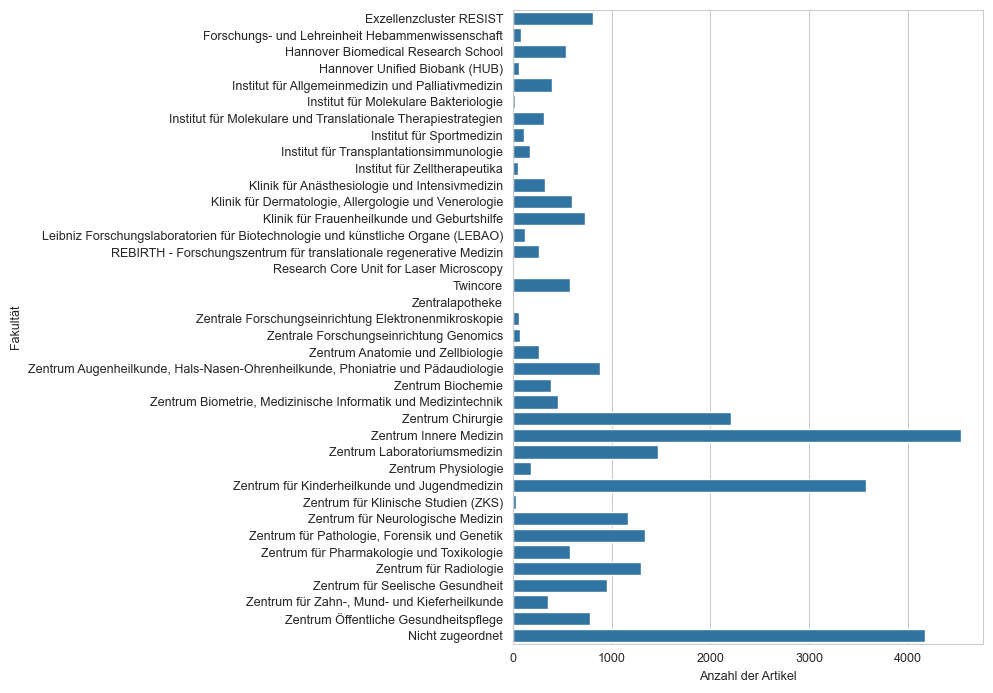

In [50]:
df_plot = df_with_inst.groupby(['inst_name'], dropna=False)['openalex_id'].count().reset_index()
df_plot.fillna('Nicht zugeordnet', inplace=True)

fig, ax = plt.subplots(figsize=(10, 7))

sns.barplot(data=df_plot, 
            x='openalex_id', 
            y='inst_name',
            ax=ax)

ax.set(xlabel='Anzahl der Artikel', ylabel='Fakultät')

plt.tight_layout()

plt.show()

In [51]:
df_plot[df_plot.inst_name != 'Nicht zugeordnet'].openalex_id.sum() / df_plot.openalex_id.sum()

0.8608608608608609